# Bloch Circle Visualisation

A qubit in state $a|0\rangle + b|1\rangle$ (with real $a, b$) can be visualised as a vector $(a, b)$ on the unit circle.

This notebook shows how common single-qubit gates move the state around the Bloch circle.

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from bloch_circle import plot_bloch_circle

%matplotlib inline

## 1. The $|0\rangle$ state

We start with a qubit in $|0\rangle$. This is the vector $(1, 0)$ — pointing to the right on the circle.

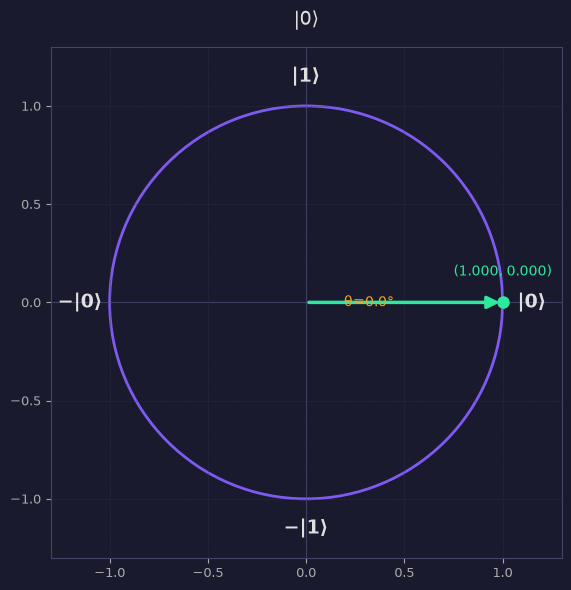

In [8]:
sv0 = Statevector.from_label('0')
plot_bloch_circle(sv0, title='|0⟩');

## 2. Applying the X gate

The X gate flips $|0\rangle \leftrightarrow |1\rangle$. On the Bloch circle this swaps the $a$ and $b$ coordinates, reflecting the vector across the diagonal.

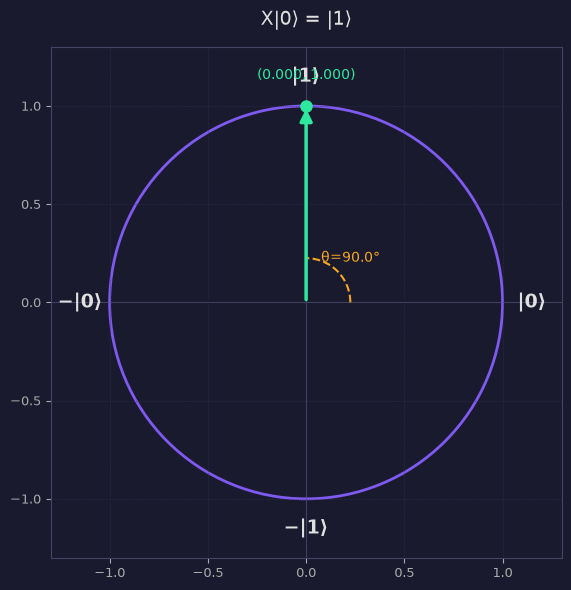

In [9]:
qc = QuantumCircuit(1)
qc.x(0)
sv_x = Statevector.from_label('0').evolve(qc)
plot_bloch_circle(sv_x, title='X|0⟩ = |1⟩');

The vector now points straight up — the $|1\rangle$ state at $(0, 1)$.

## 3. Applying the Z gate

The Z gate maps $|0\rangle \to |0\rangle$ and $|1\rangle \to -|1\rangle$. It flips the $b$ component, which is a reflection across the horizontal axis on the Bloch circle.

Let's start from $|1\rangle$ so the effect is visible:

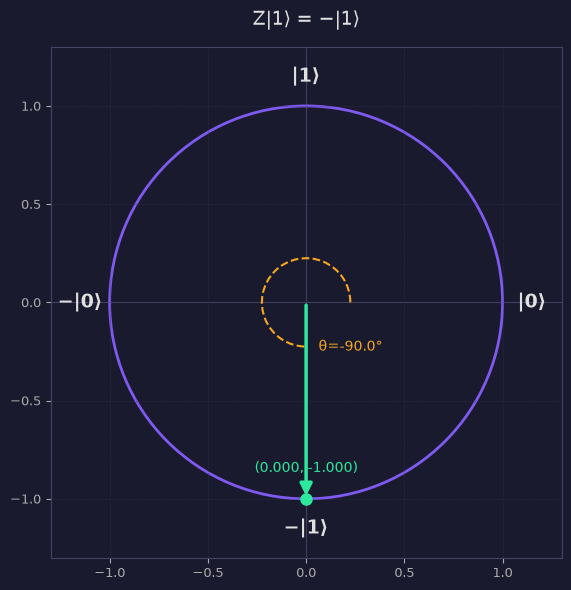

In [10]:
qc_z = QuantumCircuit(1)
qc_z.x(0)   # prepare |1⟩
qc_z.z(0)   # apply Z
sv_z = Statevector.from_label('0').evolve(qc_z)
plot_bloch_circle(sv_z, title='Z|1⟩ = −|1⟩');

The vector is now at $(0, -1)$ — the $-|1\rangle$ state, reflected downward.

## 4. Applying the H (Hadamard) gate

The Hadamard gate creates an equal superposition:
$$H|0\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$$

On the Bloch circle this puts the vector at 45°.

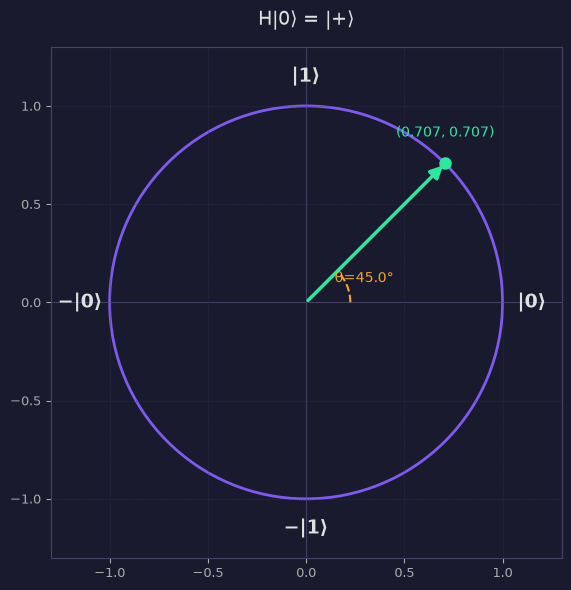

In [5]:
qc_h = QuantumCircuit(1)
qc_h.h(0)
sv_h = Statevector.from_label('0').evolve(qc_h)
plot_bloch_circle(sv_h, title='H|0⟩ = |+⟩');

And applying H to $|1\rangle$ gives the $|-\rangle$ state at 135°:

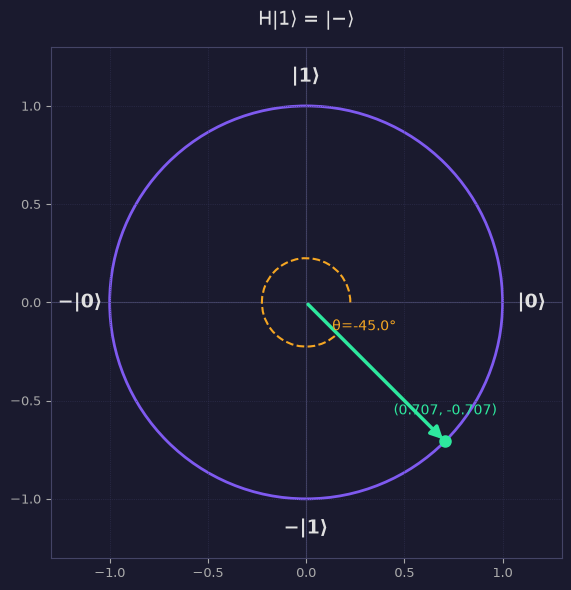

In [6]:
qc_hm = QuantumCircuit(1)
qc_hm.x(0)  # prepare |1⟩
qc_hm.h(0)  # apply H
sv_hm = Statevector.from_label('0').evolve(qc_hm)
plot_bloch_circle(sv_hm, title='H|1⟩ = |−⟩');

## 5. What about complex states?

The Bloch circle only works when both amplitudes are real. If we apply a gate that introduces a complex phase (like the S gate), we get an error:

In [7]:
qc_s = QuantumCircuit(1)
qc_s.h(0)
qc_s.s(0)  # introduces a phase of i on |1⟩
sv_s = Statevector.from_label('0').evolve(qc_s)

try:
    plot_bloch_circle(sv_s)
except ValueError as e:
    print(f"Cannot plot: {e}")

Cannot plot: The qubit state has complex amplitudes — cannot be represented on a Bloch circle.
  amplitudes = (0.7071067811865475+0j), 0.7071067811865475j


For states with complex amplitudes, you'd need the full 3D Bloch **sphere** instead.